<a href="https://colab.research.google.com/github/Albertovillarraga1309/Pattern_recognition/blob/main/Introduccion_reconocimiento_patrones_Python_no_modificar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introducción al reconocimiento de patrones con Python

**Notebook de apoyo para clase**

Este cuaderno sigue la secuencia conceptual de la presentación : imágenes digitales, operaciones aritméticas y lógicas, procesamiento, análisis, reconocimiento de patrones, computación gráfica, visión por computador, análisis de un grano de arroz, transformaciones geométricas e histogramas.

La idea no es solo ejecutar código, sino comprender **qué representa cada operación y para qué se utiliza**.

## 0. Preparación del entorno

Usaremos:
- **NumPy** para representar imágenes como matrices.
- **OpenCV** para operaciones de procesamiento y visión.
- **Matplotlib** para visualizar imágenes, perfiles e histogramas.

Los ejemplos principales generan sus propias imágenes, por lo que el notebook puede ejecutarse sin descargar fotografías adicionales.

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)

NumPy: 2.0.2
OpenCV: 5.0.0


# 1. ¿Qué es una imagen digital?

Una imagen digital puede representarse como una **matriz de píxeles**. En una imagen en escala de grises cada posición de la matriz almacena un valor de intensidad. En 8 bits, normalmente:

- `0` representa negro.
- `255` representa blanco.
- Los valores intermedios representan distintos tonos de gris.

[[  0  40  80 120]
 [ 30  70 110 150]
 [ 60 100 160 200]
 [ 90 140 210 255]]


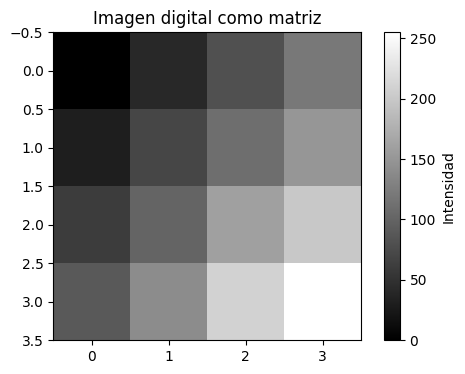

In [ ]:
imagen = np.array([
    [0, 40, 80, 120],
    [30, 70, 110, 150],
    [60, 100, 160, 200],
    [90, 140, 210, 255]
], dtype=np.uint8)

print(imagen)
plt.imshow(imagen, cmap="gray", vmin=0, vmax=255)
plt.title("Imagen digital como matriz")
plt.colorbar(label="Intensidad")
plt.show()

## 1.1 Zoom y visualización de píxeles

Al ampliar una imagen no aparecen píxeles nuevos con información original; simplemente se hacen más visibles los existentes. Aquí creamos una pequeña imagen y la mostramos ampliada con interpolación desactivada.

In [ ]:
pequena = np.array([
    [20, 20, 220, 220],
    [20, 20, 220, 220],
    [220, 220, 40, 40],
    [220, 220, 40, 40]
], dtype=np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(pequena, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
plt.xticks(range(4)); plt.yticks(range(4))
plt.grid()
plt.title("Zoom: los píxeles se observan como bloques")
plt.show()

## 1.2 Coordenadas de una imagen

En Python/OpenCV se accede normalmente como `imagen[y, x]`, es decir, primero la **fila** y luego la **columna**. Conceptualmente podemos hablar de `I(x,y)` para indicar la intensidad en la posición `(x,y)`.

In [ ]:
x, y = 2, 1
valor = imagen[y, x]
print(f"Píxel (x={x}, y={y}) = {valor}")

# 2. Imágenes a color: modelo RGB

Una imagen RGB posee tres canales: **R** (rojo), **G** (verde) y **B** (azul). Cada píxel puede representarse como `[R,G,B]`.

In [ ]:
rgb = np.zeros((150, 300, 3), dtype=np.uint8)
rgb[:, :100] = [255, 0, 0]      # rojo
rgb[:, 100:200] = [0, 255, 0]  # verde
rgb[:, 200:] = [0, 0, 255]     # azul

plt.imshow(rgb)
plt.title("Imagen RGB")
plt.axis("off")
plt.show()

## 2.1 Separación de canales RGB

In [ ]:
R = rgb[:,:,0]
G = rgb[:,:,1]
B = rgb[:,:,2]

fig, ax = plt.subplots(1,3, figsize=(10,3))
for a, canal, titulo in zip(ax, [R,G,B], ["R", "G", "B"]):
    a.imshow(canal, cmap="gray", vmin=0, vmax=255)
    a.set_title(titulo); a.axis("off")
plt.show()

## 2.2 Conversión de color a escala de grises

La presentación usa una combinación ponderada de los canales RGB. OpenCV realiza una conversión equivalente mediante `cvtColor`.

In [ ]:
gris_rgb = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
plt.imshow(gris_rgb, cmap="gray", vmin=0, vmax=255)
plt.title("RGB → escala de grises")
plt.axis("off")
plt.show()

# 3. Operaciones sobre píxeles

Una operación digital transforma los valores de intensidad para producir una nueva imagen. Veremos brillo, negativo y umbral.

In [ ]:
base = np.tile(np.linspace(0,255,256,dtype=np.uint8), (100,1))
mas_brillante = np.clip(base.astype(np.float32)*1.5, 0, 255).astype(np.uint8)
mas_oscura = np.clip(base.astype(np.float32)*0.5, 0, 255).astype(np.uint8)
negativo = 255 - base
_, umbral = cv2.threshold(base, 128, 255, cv2.THRESH_BINARY)

fig, ax = plt.subplots(2,2, figsize=(10,5))
for a, im, t in zip(ax.ravel(), [mas_brillante, mas_oscura, negativo, umbral],
                    ["I × 1.5", "I × 0.5", "255 - I", "I > 128"]):
    a.imshow(im, cmap="gray", vmin=0, vmax=255); a.set_title(t); a.axis("off")
plt.show()

# 4. Operaciones aritméticas entre imágenes

Las imágenes pueden combinarse píxel a píxel. Para que la operación tenga sentido, deben tener dimensiones compatibles.

## 4.1 Suma ponderada

La suma ponderada puede expresarse como `Y = a1*X1 + a2*X2`. Es útil para fusionar imágenes o crear transiciones.

In [ ]:
x1 = np.zeros((180,240), dtype=np.uint8)
cv2.circle(x1, (80,90), 55, 220, -1)
x2 = np.zeros_like(x1)
cv2.rectangle(x2, (110,40), (210,140), 180, -1)

y = cv2.addWeighted(x1, 0.5, x2, 0.5, 0)

fig, ax = plt.subplots(1,3, figsize=(11,3))
for a, im, t in zip(ax,[x1,x2,y],["X1","X2","Y=0.5X1+0.5X2"]):
    a.imshow(im,cmap="gray",vmin=0,vmax=255); a.set_title(t); a.axis("off")
plt.show()

## 4.2 Promedio de imágenes

Promediar varias capturas de una escena estática puede reducir ruido aleatorio.

In [ ]:
rng = np.random.default_rng(10)
limpia = np.full((150,220), 100, dtype=np.float32)
cv2.circle(limpia, (110,75), 40, 200, -1)
ruidosas=[]
for _ in range(12):
    ruido = rng.normal(0,25,limpia.shape)
    ruidosas.append(np.clip(limpia+ruido,0,255))
promedio = np.mean(ruidosas, axis=0)

fig,ax=plt.subplots(1,2,figsize=(9,3))
ax[0].imshow(ruidosas[0],cmap="gray",vmin=0,vmax=255); ax[0].set_title("Una captura ruidosa")
ax[1].imshow(promedio,cmap="gray",vmin=0,vmax=255); ax[1].set_title("Promedio de 12 capturas")
for a in ax: a.axis("off")
plt.show()

## 4.3 Resta de imágenes

La resta resalta cambios entre dos imágenes. Usamos diferencia absoluta para evitar valores negativos.

In [ ]:
antes = np.zeros((160,240), dtype=np.uint8)
cv2.rectangle(antes,(20,50),(80,110),180,-1)
despues = antes.copy()
cv2.rectangle(despues,(145,50),(205,110),220,-1)

diferencia = cv2.absdiff(despues, antes)

fig,ax=plt.subplots(1,3,figsize=(10,3))
for a,im,t in zip(ax,[antes,despues,diferencia],["Antes","Después","Diferencia"]):
    a.imshow(im,cmap="gray",vmin=0,vmax=255); a.set_title(t); a.axis("off")
plt.show()

## 4.4 Detección de movimiento con dos cuadros

En video puede compararse el cuadro actual con el anterior. Aquí simulamos dos cuadros para que el ejemplo sea ejecutable sin cámara.

In [ ]:
f1 = np.zeros((150,250), dtype=np.uint8)
cv2.rectangle(f1,(40,55),(90,105),255,-1)
f2 = np.zeros_like(f1)
cv2.rectangle(f2,(80,55),(130,105),255,-1)

d = cv2.absdiff(f2,f1)
_, movimiento = cv2.threshold(d,30,255,cv2.THRESH_BINARY)

fig,ax=plt.subplots(1,3,figsize=(10,3))
for a,im,t in zip(ax,[f1,f2,movimiento],["Cuadro t-1","Cuadro t","Movimiento detectado"]):
    a.imshow(im,cmap="gray"); a.set_title(t); a.axis("off")
plt.show()

## 4.5 Multiplicación por una constante

Si `0 < k < 1` la imagen se oscurece; si `k > 1` se aclara, teniendo cuidado de limitar valores a `[0,255]`.

In [ ]:
k1, k2 = 0.5, 1.8
oscura = np.clip(base.astype(float)*k1,0,255).astype(np.uint8)
clara = np.clip(base.astype(float)*k2,0,255).astype(np.uint8)
fig,ax=plt.subplots(1,2,figsize=(9,3))
ax[0].imshow(oscura,cmap="gray",vmin=0,vmax=255); ax[0].set_title("k=0.5")
ax[1].imshow(clara,cmap="gray",vmin=0,vmax=255); ax[1].set_title("k=1.8")
for a in ax: a.axis("off")
plt.show()

## 4.6 Multiplicación entre imágenes: máscara

Una máscara binaria permite conservar una región de interés y eliminar el resto.

In [ ]:
original = np.tile(np.linspace(20,240,240,dtype=np.uint8),(160,1))
mascara = np.zeros_like(original)
cv2.circle(mascara,(120,80),55,255,-1)
resultado = cv2.bitwise_and(original,original,mask=mascara)
fig,ax=plt.subplots(1,3,figsize=(10,3))
for a,im,t in zip(ax,[original,mascara,resultado],["Original","Máscara","Resultado"]):
    a.imshow(im,cmap="gray",vmin=0,vmax=255); a.set_title(t); a.axis("off")
plt.show()

# 5. Operaciones lógicas

Se aplican principalmente a imágenes binarias. `AND` conserva la intersección, `OR` la unión, `XOR` las diferencias y `NOT` invierte 0/1.

In [ ]:
A=np.zeros((150,220),dtype=np.uint8); B=np.zeros_like(A)
cv2.rectangle(A,(35,35),(125,115),255,-1)
cv2.circle(B,(130,75),55,255,-1)
ops=[A,B,cv2.bitwise_and(A,B),cv2.bitwise_or(A,B),cv2.bitwise_xor(A,B),cv2.bitwise_not(A)]
tit=["A","B","AND","OR","XOR","NOT(A)"]
fig,ax=plt.subplots(2,3,figsize=(10,6))
for a,im,t in zip(ax.ravel(),ops,tit):
    a.imshow(im,cmap="gray",vmin=0,vmax=255); a.set_title(t); a.axis("off")
plt.show()

# 6. Procesamiento de imágenes

En procesamiento de imágenes la **entrada es una imagen y la salida sigue siendo una imagen**. Ejemplos: reducción de ruido, contraste, filtrado, realce de bordes y segmentación.

In [ ]:
rng=np.random.default_rng(3)
obj=np.zeros((200,300),dtype=np.uint8)+50
cv2.circle(obj,(150,100),55,180,-1)
ruido=rng.normal(0,30,obj.shape)
degradada=np.clip(obj.astype(float)+ruido,0,255).astype(np.uint8)
filtrada=cv2.GaussianBlur(degradada,(7,7),0)
contraste=cv2.equalizeHist(filtrada)
bordes=cv2.Canny(filtrada,80,150)
_,segmentada=cv2.threshold(filtrada,120,255,cv2.THRESH_BINARY)

imgs=[degradada,filtrada,contraste,bordes,segmentada]
tits=["Degradada","Reducción de ruido","Contraste","Bordes","Segmentación"]
fig,ax=plt.subplots(1,5,figsize=(15,3))
for a,im,t in zip(ax,imgs,tits):
    a.imshow(im,cmap="gray"); a.set_title(t); a.axis("off")
plt.show()

# 7. Análisis de imágenes

En análisis de imágenes, la salida ya no tiene que ser otra imagen: puede ser una **medición**, una **interpretación** o una **decisión**.

Ejemplo: detectar objetos y medir su área.

In [ ]:
binaria=np.zeros((220,320),dtype=np.uint8)
cv2.circle(binaria,(80,100),35,255,-1)
cv2.rectangle(binaria,(150,60),(220,140),255,-1)
cv2.circle(binaria,(270,160),22,255,-1)
contornos,_=cv2.findContours(binaria,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
areas=[cv2.contourArea(c) for c in contornos]
print("Número de objetos:",len(contornos))
print("Áreas:",areas)

## 7.1 Etapas de un sistema de análisis de imágenes

1. Adquisición.
2. Preprocesamiento.
3. Segmentación.
4. Extracción de características.
5. Clasificación.

El siguiente ejemplo resume esas etapas con un objeto sintético.

In [ ]:
# 1) Adquisición: imagen sintética
adq=np.zeros((180,260,3),dtype=np.uint8)
adq[:]=[40,40,40]
cv2.circle(adq,(130,90),50,(40,190,230),-1)
# 2) Preprocesamiento
g=cv2.cvtColor(adq,cv2.COLOR_BGR2GRAY)
g=cv2.GaussianBlur(g,(5,5),0)
# 3) Segmentación
_,seg=cv2.threshold(g,100,255,cv2.THRESH_BINARY)
# 4) Características
cont,_=cv2.findContours(seg,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
c=max(cont,key=cv2.contourArea)
area=cv2.contourArea(c); per=cv2.arcLength(c,True)
circ=4*np.pi*area/(per**2)
# 5) Clasificación por regla
clase="circular" if circ>0.8 else "no circular"
print(f"Área={area:.1f}, Perímetro={per:.1f}, Circularidad={circ:.3f}, Clase={clase}")

# 8. Reconocimiento de patrones

El flujo conceptual es:

**Objeto → características → clasificador → clase**

Aquí construiremos un pequeño clasificador por distancia a centroides usando dos características: área y circularidad.

In [ ]:
datos=np.array([
    [3000,0.90], [3400,0.88], [2800,0.92],   # círculos
    [4200,0.65], [3900,0.62], [4500,0.60]    # rectángulos
],dtype=float)
etiquetas=np.array(["circular"]*3+["rectangular"]*3)

cent_circ=datos[etiquetas=="circular"].mean(axis=0)
cent_rect=datos[etiquetas=="rectangular"].mean(axis=0)

nuevo=np.array([3200,0.86])
# Normalizamos el área para que no domine la distancia
escala=np.array([1000,1.0])
d1=np.linalg.norm((nuevo-cent_circ)/escala)
d2=np.linalg.norm((nuevo-cent_rect)/escala)
pred="circular" if d1<d2 else "rectangular"
print("Nuevo objeto:",nuevo)
print("Clase predicha:",pred)

# 9. Computación gráfica

La presentación diferencia dos ideas:
- **Visión por computador:** imagen → información.
- **Computación gráfica:** modelo → imagen.

Aquí generamos una imagen a partir de formas geométricas.

In [ ]:
canvas=np.zeros((300,400,3),dtype=np.uint8)+240
cv2.circle(canvas,(120,150),70,(80,120,240),-1)
cv2.rectangle(canvas,(220,80),(350,220),(220,140,60),-1)
cv2.line(canvas,(30,270),(370,270),(40,40,40),4)
plt.imshow(cv2.cvtColor(canvas,cv2.COLOR_BGR2RGB))
plt.title("Imagen generada a partir de un modelo geométrico")
plt.axis("off")
plt.show()

# 10. Visión por computador

La visión por computador integra adquisición, procesamiento, análisis, reconocimiento de patrones y decisión. En este ejemplo detectamos una figura y decidimos si es aproximadamente circular.

In [ ]:
entrada=np.zeros((240,340,3),dtype=np.uint8)
entrada[:]=[30,30,30]
cv2.circle(entrada,(170,120),65,(240,240,240),-1)

g=cv2.cvtColor(entrada,cv2.COLOR_BGR2GRAY)
_,b=cv2.threshold(g,120,255,cv2.THRESH_BINARY)
cont,_=cv2.findContours(b,cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
c=max(cont,key=cv2.contourArea)
A=cv2.contourArea(c); P=cv2.arcLength(c,True)
C=4*np.pi*A/(P**2)
decision="Objeto circular" if C>0.80 else "Objeto no circular"
print("Circularidad:",round(C,3))
print("Decisión:",decision)

# 11. Ejemplo integrador: análisis de un grano de arroz

Siguiendo el ejemplo de la presentación, el objetivo es:
1. Segmentar el grano.
2. Calcular su área en píxeles.
3. Calcular su tono de gris promedio.
4. Estudiar un perfil de intensidad.

In [ ]:
# Generamos un grano de arroz sintético sobre un fondo oscuro
arroz=np.zeros((220,360),dtype=np.uint8)+35
cv2.ellipse(arroz,(180,110),(95,28),-12,0,360,205,-1)
# agregamos ligera variación de intensidad
rng=np.random.default_rng(7)
arroz=np.clip(arroz.astype(float)+rng.normal(0,4,arroz.shape),0,255).astype(np.uint8)
plt.imshow(arroz,cmap="gray",vmin=0,vmax=255)
plt.title("Grano de arroz sintético")
plt.axis("off")
plt.show()

## 11.1 Perfil de intensidad

Un perfil de intensidad toma una fila o columna de la imagen y grafica cómo cambia la intensidad.

In [ ]:
fila=arroz[110,:]
plt.plot(fila)
plt.xlabel("Posición x")
plt.ylabel("Intensidad")
plt.title("Perfil de intensidad en y=110")
plt.grid(alpha=.3)
plt.show()

## 11.2 Umbralización para segmentar el arroz

In [ ]:
T=100
_,mascara_arroz=cv2.threshold(arroz,T,255,cv2.THRESH_BINARY)
plt.imshow(mascara_arroz,cmap="gray")
plt.title(f"Segmentación con T={T}")
plt.axis("off")
plt.show()

## 11.3 Cálculo del área en píxeles

El área se obtiene contando cuántos píxeles pertenecen al objeto segmentado.

In [ ]:
area_px=np.count_nonzero(mascara_arroz)
print("Área del grano =",area_px,"píxeles")

## 11.4 Tono de gris promedio

Calculamos el promedio solo en los píxeles que pertenecen al grano.

In [ ]:
promedio_gris=cv2.mean(arroz,mask=mascara_arroz)[0]
print(f"Tono de gris promedio = {promedio_gris:.2f}")

# 12. Transformaciones geométricas

Las transformaciones cambian la posición, orientación o tamaño de una imagen. La presentación incluye **traslación, rotación y escala**.

In [ ]:
img=np.zeros((220,300),dtype=np.uint8)
cv2.rectangle(img,(100,70),(180,150),220,-1)
h,w=img.shape

M_t=np.float32([[1,0,45],[0,1,25]])
tras=cv2.warpAffine(img,M_t,(w,h))
M_r=cv2.getRotationMatrix2D((w//2,h//2),35,1.0)
rot=cv2.warpAffine(img,M_r,(w,h))
esc=cv2.resize(img,None,fx=0.65,fy=0.65,interpolation=cv2.INTER_LINEAR)

fig,ax=plt.subplots(1,4,figsize=(12,3))
for a,im,t in zip(ax,[img,tras,rot,esc],["Original","Traslación","Rotación","Escala 0.65"]):
    a.imshow(im,cmap="gray"); a.set_title(t); a.axis("off")
plt.show()

## 12.1 ¿Qué ocurre al transformar una imagen?

Cuando las nuevas coordenadas no coinciden exactamente con píxeles originales, el sistema debe estimar intensidades mediante **interpolación**. Comparemos vecino más cercano y bilineal al ampliar.

In [ ]:
mini=np.array([[0,80,160],[40,120,200],[80,180,255]],dtype=np.uint8)
nn=cv2.resize(mini,(300,300),interpolation=cv2.INTER_NEAREST)
bil=cv2.resize(mini,(300,300),interpolation=cv2.INTER_LINEAR)
fig,ax=plt.subplots(1,2,figsize=(8,4))
ax[0].imshow(nn,cmap="gray",vmin=0,vmax=255); ax[0].set_title("Vecino más cercano")
ax[1].imshow(bil,cmap="gray",vmin=0,vmax=255); ax[1].set_title("Bilineal")
for a in ax: a.axis("off")
plt.show()

# 13. Histograma de una imagen

El histograma cuenta cuántos píxeles existen para cada nivel de intensidad. Es una representación global de la distribución tonal de la imagen.

In [ ]:
hist=cv2.calcHist([arroz],[0],None,[256],[0,256]).ravel()
plt.plot(hist)
plt.xlabel("Nivel de gris")
plt.ylabel("Número de píxeles")
plt.title("Histograma del ejemplo del arroz")
plt.xlim(0,255)
plt.show()

## 13.1 Ejemplo manual con una imagen pequeña

Construimos una matriz pequeña y contamos la frecuencia de cada intensidad para entender de dónde sale el histograma.

In [ ]:
m=np.array([
 [0,0,0,1,1,2],
 [0,0,1,1,2,2],
 [0,1,1,2,2,3],
 [1,1,2,2,3,3]
],dtype=np.uint8)
valores,frecuencias=np.unique(m,return_counts=True)
print(m)
print("\nNivel -> frecuencia")
for v,f in zip(valores,frecuencias):
    print(f"{v:>3} -> {f}")
plt.bar(valores,frecuencias)
plt.xlabel("Nivel")
plt.ylabel("Frecuencia")
plt.title("Histograma construido manualmente")
plt.show()

# 14. Actividad de integración

Modifique el ejemplo del grano de arroz y responda:

1. ¿Qué ocurre con el área calculada si aumenta el umbral `T`?
2. ¿Qué ocurre si se agrega ruido a la imagen antes de segmentar?
3. Aplique un filtro Gaussiano antes de la segmentación. ¿Mejora el resultado?
4. Calcule área, perímetro y circularidad del grano.
5. Cambie la orientación del grano y compruebe si el área debería mantenerse aproximadamente constante.
6. Compare los histogramas del fondo y del objeto.

Esta actividad conecta **procesamiento → segmentación → características → análisis → decisión**.

In [ ]:
# Espacio de trabajo para la actividad
# Pruebe distintos valores de T
T = 100
_, prueba = cv2.threshold(arroz, T, 255, cv2.THRESH_BINARY)
print("Área con T =", T, ":", np.count_nonzero(prueba))

# 15. Resumen conceptual

- Una imagen digital es una **matriz de píxeles**.
- Las operaciones aritméticas y lógicas modifican o combinan imágenes píxel a píxel.
- El **procesamiento de imágenes** produce otra imagen.
- El **análisis de imágenes** obtiene mediciones, interpretaciones o decisiones.
- El **reconocimiento de patrones** usa características para asignar objetos a clases.
- La **computación gráfica** genera imágenes a partir de modelos.
- La **visión por computador** integra adquisición, procesamiento, análisis y reconocimiento para producir información útil.
- La **segmentación** separa objetos o regiones de interés.
- Las **transformaciones geométricas** modifican posición, orientación o escala.
- Los **histogramas** describen la distribución de intensidades.